# 무역구제 조사범위 분쟁 DB — 재현 노트북

`paper.md`가 인용하는 수치와 그림을 저장소의 `data/` 파일에서 다시 만든다.
마지막 절(§11)이 본문 값과 계산 값을 대조하고, 어긋나면 AssertionError로 멈춘다.

필요한 것은 파이썬 표준 라이브러리와 `matplotlib`, 그리고 그림 1·2를 그리는 Graphviz(`dot`)다.
Graphviz는 `winget install Graphviz.Graphviz`로 설치한다. 노트북은 저장소 안 어디에서 열어도
저장소 루트를 스스로 찾는다.

## §0. 준비

자료를 읽는 함수와, 같은 물품·대상국의 연속 조치를 한 물품 계열로 묶는 열쇠를 정의한다.

In [1]:
import csv
import re
from collections import Counter, defaultdict
from datetime import date
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "measures.csv").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("저장소 루트를 찾지 못했다")
    ROOT = ROOT.parent
D = ROOT / "data"


def rd(name):
    return list(csv.DictReader((D / name).open(encoding="utf-8-sig")))


measures, versions = rd("measures.csv"), rd("decree-versions.csv")
coding = {r["measure_id"]: r for r in rd("coding/coder-a.csv")}
disputes = rd("dispute-extract.csv")
cites = rd("dispute-citations.csv")
dm_links = rd("dispute-measure-links.csv")
ktc_cases, mk_links, ktc_sum = rd("ktc-cases.csv"), rd("measure-ktc-links.csv"), rd("ktc-case-summary.csv")
hsk = rd("hsk-revision-measures.csv")
annexes, guides, press = rd("annexes.csv"), rd("ktc-scope-guides.csv"), rd("ktc-press.csv")
book = rd("ktc-book-cases.csv")

OUT = {}


def put(key, val):
    OUT[key] = val
    print(f"{key}: {val}")


def section(t):
    print(f"\n## {t}")


def lineage(m):
    """같은 물품·대상국의 연속 조치를 한 계열로 묶는 열쇠."""
    s = re.sub(r"\(.*?\)|\s|ㆍ|·", "", m["base_name"])
    for a, b in [("스테인레스", "스테인리스"), ("말레이지아", "말레이시아"), ("싱가폴", "싱가포르"),
                 ("폴리에틸렌테레프탈레이트", "PET"), ("의부과", "부과")]:
        s = s.replace(a, b)
    return s

## §1. DB 구성 (본문 V.1, 표 9)

층별 건수와 원자료의 규모.

In [2]:
put("판", len(versions))
put("조치", len(measures))
put("조치_연대", dict(sorted(Counter(m["effective_date"][:3] + "0년대" for m in measures).items())))
put("조치_계열", len({lineage(m) for m in measures}))
put("별표", len(annexes))
put("결정", len(disputes))
put("결정_기관", dict(Counter(d["forum"] for d in disputes).most_common()))
put("결정_연관", dict(Counter(d["relevance"] for d in disputes).most_common()))
put("결정문_묶음", len({d["decision_group"] for d in disputes}))
put("분쟁_연쇄", len({d["dispute_chain"] for d in disputes if d["issue_group"] != "무관"}))
put("무역위_사건", len(ktc_cases))
put("무역위_사건_종류", dict(Counter(c["case_type"] for c in ktc_cases).most_common()))
put("사건요약", len(ktc_sum))
put("사건요약_신청인", sum(bool(s["petitioners"]) for s in ktc_sum))
put("범위안내서_파일", len(guides))
put("범위안내서_사건", len({g["master_id"] for g in guides}))
put("보도자료", len(press))
put("30년사_행", len(book))
put("회신", len(cites))
put("회신_범위", sum(c["scope_related"] == "Y" for c in cites))
put("회신_범위_서로다른", len({c["reply_key"] for c in cites if c["scope_related"] == "Y"}))

판: 174
조치: 145
조치_연대: {'1990년대': 23, '2000년대': 33, '2010년대': 47, '2020년대': 42}
조치_계열: 92
별표: 191
결정: 73
결정_기관: {'조세심판원': 49, '법원': 11, '관세청 과세전적부심사': 9, '관세청 심사청구': 4}
결정_연관: {'쟁점': 57, '언급': 9, '무관': 7}
결정문_묶음: 66
분쟁_연쇄: 43
무역위_사건: 229
무역위_사건_종류: {'원심': 126, '종료재심사': 60, '재심(종류 미상)': 35, '중간재심사': 4, '가격약속 검토': 2, '중간재심사(부과대상 제외)': 2}
사건요약: 206
사건요약_신청인: 203
범위안내서_파일: 80
범위안내서_사건: 60
보도자료: 124
30년사_행: 156
회신: 81
회신_범위: 42
회신_범위_서로다른: 24


## §2. 층 사이의 연결 (본문 V.7)

분쟁과 조치, 조치와 무역위원회 사건의 연결률과 연결 방법.

In [3]:
rel = [d for d in disputes if d["issue_group"] != "무관"]
linked = {l["dispute_id"] for l in dm_links if l["measure_id"]}
put("분쟁_대상", len(rel))
put("분쟁_연결", len([d for d in rel if d["dispute_id"] in linked]))
meth = Counter(re.sub(r"\(결정일 기준\)", "", l["method"]) for l in dm_links if l["measure_id"])
put("분쟁_연결방법", dict(meth.most_common()))
put("조치_사건연결", sum(bool(l["master_id"]) for l in mk_links))
sumd = {s["master_id"]: s for s in ktc_sum}
pet = [l for l in mk_links if l["master_id"] in sumd and sumd[l["master_id"]]["petitioners"]]
put("조치_신청인", len(pet))

분쟁_대상: 57
분쟁_연결: 55
분쟁_연결방법: {'부령 번호+공포일': 50, '제명+수입기간': 11, '보조 키2(HSK)': 6, '수작업': 5, '부령 번호': 3, '보조 키1(물품명)': 1}
조치_사건연결: 145
조치_신청인: 129


## §3. 범위 문언 코딩 (본문 V.3, VI.1, 표 11)

부과대상 조건과 제외 요건의 유형 분포.

In [4]:
put("부과조건_요약", dict(Counter(c["scope_positive_summary"] for c in coding.values()).most_common()))
put("제외_요약", dict(Counter(c["exclusion_summary"] for c in coding.values()).most_common()))
put("제외_위치", dict(Counter(c["exclusion_location"] for c in coding.values()).most_common()))
put("용도조건", sum(c["use_based"] == "Y" for c in coding.values()))
tcount = Counter()
for c in coding.values():
    for part in ("scope_positive_types", "exclusion_types"):
        for t in set(c[part].split(";")) - {""}:
            tcount[(part, t)] += 1
put("유형별_조치수", {f"{'부과' if p.startswith('scope') else '제외'}_{t}": n for (p, t), n in sorted(tcount.items())})
by_dec = defaultdict(lambda: [0, 0])
for m in measures:
    k = m["effective_date"][:3] + "0년대"
    by_dec[k][0] += 1
    by_dec[k][1] += coding[m["measure_id"]]["exclusion_present"] == "Y"
put("연대별_제외요건", {k: f"{v[1]}/{v[0]}" for k, v in sorted(by_dec.items())})

부과조건_요약: {'없음': 59, '복합': 44, '규격': 33, '가공상태': 5, '용도': 4}
제외_요약: {'없음': 81, '복합': 34, '가공상태': 15, '규격': 9, '용도': 5, '제품지정': 1}
제외_위치: {'없음': 81, '본문': 37, '별표': 23, '둘다': 4}
용도조건: 29
유형별_조치수: {'제외_가공상태': 41, '제외_규격': 41, '제외_분류': 4, '제외_용도': 21, '제외_제품지정': 21, '부과_가공상태': 47, '부과_규격': 74, '부과_용도': 10, '부과_제품지정': 1}
연대별_제외요건: {'1990년대': '7/23', '2000년대': '16/33', '2010년대': '20/47', '2020년대': '21/42'}


## §4. 분쟁: 쟁점, 결과, 판단 기준, 소요 기간 (본문 VI.3, VI.4, 표 13)

조사범위 분쟁만 골라 결정기관의 판단 기준과 납세자 승소를 센다.

In [5]:
put("쟁점", dict(Counter(d["issue_group"] for d in rel).most_common()))
scope = [d for d in rel if d["issue_group"].startswith("조사범위")]
put("범위분쟁_결정", len(scope))
put("범위분쟁_결정문", len({d["decision_group"] for d in scope}))
put("범위분쟁_분쟁", len({d["dispute_chain"] for d in scope}))
put("범위분쟁_기관", dict(Counter(d["forum"] for d in scope).most_common()))
wins = defaultdict(lambda: [0, 0])
for d in rel:
    if d["outcome"] == "각하":
        continue
    g = "조사범위" if d["issue_group"].startswith("조사범위") else d["issue_group"]
    wins[g][0] += 1
    wins[g][1] += d["taxpayer_win"] == "Y"
put("본안_납세자승", {k: f"{v[1]}/{v[0]}" for k, v in sorted(wins.items())})
sw = defaultdict(lambda: [0, 0])
for d in scope:
    if d["outcome"] != "각하":
        sw[d["forum"]][0] += 1
        sw[d["forum"]][1] += d["taxpayer_win"] == "Y"
put("범위분쟁_기관별_승", {k: f"{v[1]}/{v[0]}" for k, v in sw.items()})
crit = Counter()
for d in scope:
    for t in set(d["scope_criteria_used"].split(";")) - {""}:
        crit[t] += 1
put("판단기준", dict(crit.most_common()))
put("판단기준_분류포함", sum("분류" in d["scope_criteria_used"] for d in scope))
put("범위분쟁_연도", dict(sorted(Counter(d["decision_date"][:4] for d in scope).items())))
put("범위분쟁_무역위언급", sum(bool(d["ktc_reference"]) for d in scope))

# 조치 시행부터 결정까지
mdate = {m["measure_id"]: m["effective_date"] for m in measures}
lags = []
for d in scope:
    ms = [l["measure_id"] for l in dm_links if l["dispute_id"] == d["dispute_id"] and l["measure_id"]]
    if ms:
        first = min(mdate[x] for x in ms)
        lags.append((date.fromisoformat(d["decision_date"]) - date.fromisoformat(first)).days / 365.25)
lags.sort()
put("시행후_결정_중앙값_년", round(lags[len(lags) // 2], 1))
put("시행후_결정_범위_년", (round(lags[0], 1), round(lags[-1], 1)))

쟁점: {'조사범위': 24, '공급자·세율': 12, '불복 적격': 11, '기타': 6, '조사범위 부수': 2, '가격약속·과세가격': 2}
범위분쟁_결정: 26
범위분쟁_결정문: 22
범위분쟁_분쟁: 16
범위분쟁_기관: {'조세심판원': 16, '관세청 과세전적부심사': 6, '관세청 심사청구': 2, '법원': 2}
본안_납세자승: {'가격약속·과세가격': '0/2', '공급자·세율': '2/12', '기타': '0/6', '불복 적격': '0/1', '조사범위': '5/26'}
범위분쟁_기관별_승: {'관세청 심사청구': '0/2', '조세심판원': '3/16', '법원': '0/2', '관세청 과세전적부심사': '2/6'}
판단기준: {'분류': 20, '가공상태': 17, '규격': 12, '용도': 2, '제품지정': 1}
판단기준_분류포함: 20
범위분쟁_연도: {'2002': 1, '2007': 1, '2014': 1, '2015': 2, '2016': 1, '2017': 1, '2018': 5, '2019': 1, '2021': 1, '2023': 2, '2025': 4, '2026': 6}
범위분쟁_무역위언급: 16
시행후_결정_중앙값_년: 5.7
시행후_결정_범위_년: (0.2, 11.4)


## §5. 조치 단위 교차표 (본문 VI.2, 표 12)

범위 문언 유형별로 조사범위 분쟁이 걸린 조치의 비율. 계열 단위 집계를 함께 낸다.

In [6]:
disp_m = {l["measure_id"] for l in dm_links if l["measure_id"] and l["issue_group"].startswith("조사범위")}
put("범위분쟁_조치", len(disp_m))
lin = {m["measure_id"]: lineage(m) for m in measures}
disp_l = {lin[x] for x in disp_m}
put("범위분쟁_계열", len(disp_l))
put("계열_전체", len(set(lin.values())))


def cross(key, unit="measure"):
    t = defaultdict(lambda: [0, 0])
    if unit == "measure":
        for mid, c in coding.items():
            t[c[key]][0] += 1
            t[c[key]][1] += mid in disp_m
    else:  # 계열: 계열 안 조치 가운데 하나라도 해당 값이면 그 값으로 센다(복합이 겹치면 여러 칸)
        vals = defaultdict(set)
        for mid, c in coding.items():
            vals[lin[mid]].add(c[key])
        for l, vs in vals.items():
            for v in vs:
                t[v][0] += 1
                t[v][1] += l in disp_l
    return {k: f"{v[1]}/{v[0]}" for k, v in sorted(t.items())}


put("교차_제외요약_조치", cross("exclusion_summary"))
put("교차_부과요약_조치", cross("scope_positive_summary"))
put("교차_용도_조치", cross("use_based"))
put("교차_용도_계열", cross("use_based", "lineage"))
put("교차_제외유무_조치", cross("exclusion_present"))
top = Counter(lin[l["measure_id"]] for l in dm_links if l["measure_id"] and l["issue_group"].startswith("조사범위"))
put("범위분쟁_계열별_결정연결수", dict(top.most_common(6)))

범위분쟁_조치: 23
범위분쟁_계열: 12
계열_전체: 92
교차_제외요약_조치: {'가공상태': '2/15', '규격': '0/9', '복합': '8/34', '없음': '13/81', '용도': '0/5', '제품지정': '0/1'}
교차_부과요약_조치: {'가공상태': '0/5', '규격': '7/33', '복합': '10/44', '없음': '5/59', '용도': '1/4'}
교차_용도_조치: {'N': '17/116', 'Y': '6/29'}
교차_용도_계열: {'N': '9/73', 'Y': '3/20'}
교차_제외유무_조치: {'N': '13/81', 'Y': '10/64'}
범위분쟁_계열별_결정연결수: {'중국및인도산PET필름': 18, '중국산도자기질타일': 5, '중국산합판': 5, '중국인도네시아및태국산폴리프로필렌연신필름': 4, '일본인도및스페인산스테인리스스틸바': 3, '중국산침엽수합판': 3}


## §6. 부처 회신 (본문 VI.5, 표 14)

조사범위 회신의 기관별 채택과, 한 결정 안의 엇갈림.

In [7]:
sc = [c for c in cites if c["scope_related"] == "Y"]
put("범위회신_기관", dict(Counter(c["issuing_agency"] for c in sc).most_common()))
put("범위회신_채택", dict(Counter(c["adopted"] for c in sc).most_common()))
by_d = defaultdict(list)
for c in sc:
    by_d[c["dispute_id"]].append(c)
multi = [d for d, cs in by_d.items() if len({c["issuing_agency"] for c in cs}) >= 2]
conflict = [d for d, cs in by_d.items() if {"부과대상 포함", "부과대상 제외"} <= {c["reply_position"] for c in cs}]
put("범위회신_있는결정", len(by_d))
put("복수기관_결정", len(multi))
put("상충회신_결정", len(conflict))
dg = {d["dispute_id"]: d["decision_group"] for d in disputes}
put("상충회신_결정문", len({dg[d] for d in conflict}))
put("상충회신_결정목록", sorted(conflict))
adopt = defaultdict(Counter)
for c in sc:
    adopt[c["issuing_agency"]][c["adopted"]] += 1
put("기관별_채택", {k: dict(v) for k, v in adopt.items()})

범위회신_기관: {'무역위원회': 22, '기획재정부': 11, '관세청': 7, '세관': 2}
범위회신_채택: {'불명': 18, 'Y': 16, 'N': 8}
범위회신_있는결정: 16
복수기관_결정: 8
상충회신_결정: 5
상충회신_결정문: 4
상충회신_결정목록: ['D037', 'D039', 'D064', 'D072', 'D073']
기관별_채택: {'무역위원회': {'Y': 11, '불명': 9, 'N': 2}, '기획재정부': {'Y': 3, '불명': 5, 'N': 3}, '관세청': {'불명': 4, 'N': 3}, '세관': {'Y': 2}}


## §7. 무역위원회 사건 (본문 II.1, VI.8)

신청인, 가격약속, 물품 계열의 길이, 원심 조사 개시 추이.

In [8]:
pets = Counter()
for s in ktc_sum:
    for p in s["petitioners"].split(","):
        p = p.strip()
        if p:
            pets[re.sub(r"\(주\)|주식회사|\(사\)|\s", "", p)] += 1
put("신청인_상위", dict(pets.most_common(8)))
put("가격약속_사건", sum(s["price_undertaking"] == "Y" for s in ktc_sum))
gen = Counter(lin.values())
put("계열당_조치수_분포", dict(sorted(Counter(gen.values()).items())))
put("최장계열", gen.most_common(3))
put("범위변경재심", sum(c["case_type"] == "중간재심사(부과대상 제외)" for c in ktc_cases))
orig = Counter(c["initiation_date"][:4] for c in ktc_cases if c["case_type"] == "원심")
put("원심개시_2018_2023_범위", (min(orig[str(y)] for y in range(2018, 2024)), max(orig[str(y)] for y in range(2018, 2024))))
put("원심개시_2024_2025", (orig["2024"], orig["2025"]))

신청인_상위: {'한국합판보드협회': 20, '코오롱인더스트리': 8, '세아특수강': 7, '한국알콜산업': 6, '티케이케미칼': 6, '도레이첨단소재': 6, 'SKC': 5, '코스모화학': 5}
가격약속_사건: 30
계열당_조치수_분포: {1: 63, 2: 16, 3: 6, 4: 3, 5: 4}
최장계열: [('일본인도및스페인산스테인리스스틸바', 5), ('중국산플로트판유리', 5), ('중국및인도산PET필름', 5)]
범위변경재심: 2
원심개시_2018_2023_범위: (1, 5)
원심개시_2024_2025: (8, 8)


## §8. HSK 개정 (본문 VI.7, 표 15)

개정일에 시행 중이던 조치, 열거 번호가 영향받은 조치, 부령이 고친 조치.

In [9]:
for rev in ("2012", "2017", "2022"):
    rs = [r for r in hsk if r["revision"] == rev]
    a = [r for r in rs if r["affected"] == "Y"]
    put(f"HSK_{rev}", (len(rs), len(a), sum(r["decree_updated"] == "Y" for r in a)))

HSK_2012: (10, 0, 0)
HSK_2017: (13, 2, 0)
HSK_2022: (18, 4, 4)


## §9. 저장 형식의 규모 (본문 V.8)

원문(`data/raw/`)을 뺀 `data/` 폴더의 크기와 가장 긴 테이블의 행 수, 가장 최근 결정일.

In [10]:
data_bytes = sum(f.stat().st_size for f in D.rglob("*") if f.is_file() and "raw" not in f.relative_to(D).parts)
put("data_폴더_MB", round(data_bytes / 1e6, 1))
rows = {f.relative_to(D).as_posix(): len(rd(f.relative_to(D).as_posix())) for f in D.rglob("*.csv") if "raw" not in f.relative_to(D).parts}
put("최장_테이블", max(rows.items(), key=lambda kv: kv[1]))
put("최근_결정일", max(d["decision_date"] for d in rd("disputes.csv")))

data_폴더_MB: 2.7
최장_테이블: ('ktc-cases.csv', 229)
최근_결정일: 2026-08-19


## §10. 그림 1\~3

그림 1(불복 경로)과 그림 2(연결 구조)는 DOT 원문을 만들어 Graphviz로 그리고, 그림 3(판·조치·계열)은 날짜 축이 있어 matplotlib으로 그린다.
결과는 `research/01-db-overview/img/`에 저장되며 DOT 원문도 같은 곳에 남는다.

In [11]:
import csv
import shutil
import subprocess
from collections import Counter
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

HERE = ROOT / "research" / "01-db-overview"
IMG = HERE / "img"
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
SHADE = "0.85"          # matplotlib 회색
GRAY = "gray85"         # Graphviz 회색(같은 농도)
DOT = shutil.which("dot") or r"C:\Program Files\Graphviz\bin\dot.exe"

# 개념도가 함께 쓰는 기본값: 흑백, Malgun Gothic, 300dpi
DOT_BASE = """
  graph [fontname="Malgun Gothic", fontsize=11, dpi=300, bgcolor=white, pad=0.2];
  node  [fontname="Malgun Gothic", fontsize=10, shape=box, style="rounded", penwidth=1.0, margin="0.15,0.08"];
  edge  [fontname="Malgun Gothic", fontsize=9, penwidth=0.9, arrowsize=0.7];
"""


def render(dot_src, name):
    IMG.mkdir(exist_ok=True)
    src = IMG / f"{name}.dot"
    src.write_text(dot_src, encoding="utf-8")
    subprocess.run([DOT, "-Tpng", str(src), "-o", str(IMG / f"{name}.png")], check=True)


def save(fig, name):
    IMG.mkdir(exist_ok=True)
    fig.savefig(IMG / name, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

In [12]:
def fig1_appeal_routes():
    with open(ROOT / "data" / "dispute-extract.csv", encoding="utf-8-sig") as f:
        n = Counter(r["forum"] for r in csv.DictReader(f))

    src = f"""digraph appeal {{
  {DOT_BASE}
  rankdir=LR; nodesep=0.25; ranksep=0.45; newrank=true;
  node [width=1.9];
  labelloc=b; label=<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="6"><TR>
    <TD BGCOLOR="{GRAY}" BORDER="1" WIDTH="24" HEIGHT="12"></TD><TD ALIGN="LEFT">이 DB가 결정을 모은 경로(숫자는 결정 수)</TD>
    <TD WIDTH="20"></TD>
    <TD BORDER="1" STYLE="dashed" WIDTH="24" HEIGHT="12"></TD><TD ALIGN="LEFT">거치지 않아도 되는 단계</TD></TR></TABLE>>;

  subgraph cluster_pre {{ label="과세 전"; color=gray70; style=solid; penwidth=0.7; labelloc=t;
    pre [label="과세전적부심사\\n관세청(또는 세관)\\n{n['관세청 과세전적부심사']}건", style="rounded,filled", fillcolor={GRAY}]; }}
  subgraph cluster_tax {{ label="과세"; color=gray70; style=solid; penwidth=0.7; labelloc=t;
    tax [label="세관의 과세·처분\\n경정, 경정청구 거부", penwidth=1.8]; }}
  subgraph cluster_obj {{ label="과세 후(선택)"; color=gray70; style=solid; penwidth=0.7; labelloc=t;
    obj [label="이의신청\\n세관장", style="rounded,dashed"]; }}

  # 이의신청을 건너뛰는 선: 선이 문구를 지나가도록 문구를 노드로 둔다
  skip [shape=plaintext, style="", width=0, height=0, margin="0.06,0", fontsize=9, label="이의신청 없이 바로"];
  {{ rank=same; obj; skip; }}
  skip -> obj [style=invis];  # LR에서는 앞 노드가 아래에 놓인다
  j [shape=point, width=0.06];
  subgraph cluster_three {{ label="과세 후(셋 중 하나)"; color=gray70; style=solid; penwidth=0.7; labelloc=t;
    rev [label="심사청구\\n관세청장\\n{n['관세청 심사청구']}건", style="rounded,filled", fillcolor={GRAY}];
    trib [label="심판청구\\n조세심판원\\n{n['조세심판원']}건", style="rounded,filled", fillcolor={GRAY}];
    audit [label="감사원 심사청구\\n감사원"]; }}
  subgraph cluster_court {{ label="그다음"; color=gray70; style=solid; penwidth=0.7; labelloc=t;
    court [label="행정소송\\n법원\\n{n['법원']}건", style="rounded,filled", fillcolor={GRAY}]; }}

  pre -> tax;
  tax -> obj [style=dashed];
  obj -> j [style=dashed, arrowhead=none];
  tax -> skip [arrowhead=none];
  skip -> j [arrowhead=none];
  j -> rev; j -> trib; j -> audit;
  {{ rank=same; rev; trib; audit; }}
  audit -> trib -> rev [style=invis];  # LR에서는 앞 노드가 아래에 놓인다
  rev -> court; trib -> court; audit -> court;
}}
"""
    render(src, "fig1_appeal_routes")

In [13]:
def fig2_linkage_structure():
    src = f"""digraph linkage {{
  {DOT_BASE}
  rankdir=TB; nodesep=0.35; ranksep=0.55; newrank=true;
  node [width=2.0];

  # 왼쪽 층 이름
  L1 [group=L, width=0.8, label="기관과\\n절차", shape=plaintext, style="", fontcolor=gray25];
  L2 [group=L, width=0.8, label="공개\\n기록", shape=plaintext, style="", fontcolor=gray25];
  L3 [group=L, width=0.8, label="DB\\n테이블", shape=plaintext, style="", fontcolor=gray25];
  L1 -> L2 -> L3 [style=invis];

  # group이 같은 노드는 한 세로줄에 놓인다
  subgraph cluster_measure {{ label=<<B>조치 계열</B>>; style=filled; fillcolor=gray95; color=gray60;
    ktc [group=a, label="무역위원회\\n조사대상물품 설정·판정"];
    mof [group=b, label="재정경제부\\n부령 제정"];
    ktc_rec [group=a, label="사건 상세, 범위 안내서,\\n보도자료, 30년사 부록\\n(무역위원회 누리집)", fontsize=9];
    mof_rec [group=b, label="부령 본문과 별표\\n(국가법령정보센터\\n연혁법령)", fontsize=9];
    ktc_db [group=a, label="ktc-cases.csv", fontsize=9];
    mea_db [group=b, label=<<B>measures.csv</B>>, style="rounded,filled", fillcolor=gray20, fontcolor=white, fontsize=9];
  }}
  subgraph cluster_dispute {{ label=<<B>분쟁 계열</B>>; style=filled; fillcolor=gray95; color=gray60;
    cus [group=c, label="세관\\n적용·처분", width=1.5];
    app [group=d, label="조세심판원·관세청·법원\\n불복 결정", width=2.3];
    cus_rec [group=c, label="별도 공개 기록 없음\\n(결정문의 처분개요에\\n나타남)", style="rounded,dashed", fontsize=9, width=1.5];
    app_rec [group=d, label="결정문, 판결 요지\\n(조세심판원 결정례,\\n관세법령정보포털)", fontsize=9, width=2.3];
    dis_db [group=d, label="dispute-extract.csv", fontsize=9, width=2.3];
  }}

  {{ rank=same; L1; ktc; mof; cus; app; }}
  {{ rank=same; L2; ktc_rec; mof_rec; cus_rec; app_rec; }}
  {{ rank=same; L3; ktc_db; mea_db; dis_db; }}

  # 기관 사이의 순서
  ktc -> mof [label="부과 건의"];
  mof -> cus [label="시행"];
  cus -> app [label="불복"];

  # 기관과 기록, 기록과 테이블
  ktc -> ktc_rec [arrowhead=none]; mof -> mof_rec [arrowhead=none];
  cus -> cus_rec [arrowhead=none]; app -> app_rec [arrowhead=none];
  ktc_rec -> ktc_db; mof_rec -> mea_db; app_rec -> dis_db;

  # 테이블 사이의 연결(분쟁 쪽은 결정문이 인용한 부령 번호가 열쇠)
  ktc_db -> mea_db [dir=both, label="measure-ktc-links.csv\\n물품명·대상국·판정일", fontsize=8];
  mea_db -> dis_db [dir=both, label="dispute-measure-links.csv\\n결정문이 인용한 부령 번호·수입기간", fontsize=8];

  # 가로 순서 고정
  L1 -> ktc [style=invis]; L2 -> ktc_rec [style=invis]; L3 -> ktc_db [style=invis];
  ktc_rec -> mof_rec -> cus_rec -> app_rec [style=invis];
}}
"""
    render(src, "fig2_linkage_structure")

In [14]:
def fig3_units_plywood():
    title = "중국산 합판에 대한 덤핑방지관세 부과에 관한 규칙"
    with open(ROOT / "data" / "decree-versions.csv", encoding="utf-8-sig") as f:
        vers = [r for r in csv.DictReader(f) if r["name"] == title]
    vers.sort(key=lambda r: r["effective_date"])
    d = lambda s: date.fromisoformat(s)
    yr = lambda t: t.year + (t.timetuple().tm_yday - 1) / 365.25
    t_end = 2026.9                                     # 그림의 오른쪽 끝(작성 시점)

    fig, ax = plt.subplots(figsize=(11.8, 3.9))
    ax.set_xlim(2012.3, 2027.2)
    ax.set_ylim(-0.1, 3.75)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.set_yticks([])
    ax.set_xticks(range(2013, 2027))
    ax.tick_params(axis="x", labelsize=8)
    for y, t in [(3.2, "물품 계열"), (2.2, "조치"), (0.95, "판")]:
        ax.text(2012.35, y, t, ha="left", va="center", fontsize=9, weight="bold")

    # 판
    prev, low = -99, False
    for r in vers:
        x = yr(d(r["effective_date"]))
        low = (not low) and x - prev < 1.5          # 앞 판과 가까우면 이름표를 한 줄 내린다
        prev = x
        new = r["revision_type"] == "제정"
        ax.plot(x, 0.95, marker="o", ms=8, mfc="black" if new else "white", mec="black", zorder=3)
        dt = d(r["effective_date"])
        ax.text(x, 0.15 if low else 0.55, f"{r['promulgation_no']} {r['revision_type']}\n{dt.year}.{dt.month}",
                ha="center", va="center", fontsize=7.5, linespacing=1.25)

    # 조치: 제정일부터 다음 제정일까지
    starts = [yr(d(r["effective_date"])) for r in vers if r["revision_type"] == "제정"]
    ends = starts[1:] + [t_end]
    for k, (a, b) in enumerate(zip(starts, ends), 1):
        ax.add_patch(Rectangle((a, 1.95), b - a - 0.05, 0.5, fc=SHADE, ec="black", lw=0.8, zorder=2))
        n_ver = sum(a <= yr(d(r["effective_date"])) < b for r in vers)
        ax.text((a + b) / 2, 2.2, f"조치 {k}\n판 {n_ver}개", ha="center", va="center", fontsize=8, linespacing=1.25)
        ax.plot([a, a], [1.05, 1.95], color="0.5", lw=0.6, ls=":", zorder=1)
    ax.annotate("", xy=(t_end + 0.25, 2.2), xytext=(t_end - 0.05, 2.2),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=0.9))

    # 물품 계열
    ax.add_patch(Rectangle((starts[0], 2.95), t_end - starts[0], 0.5, fc="white", ec="black", lw=0.9, zorder=2))
    ax.text((starts[0] + t_end) / 2, 3.2, f"중국산 합판 계열: 조치 {len(starts)}개, 판 {len(vers)}개",
            ha="center", va="center", fontsize=8.5)

    # 범례
    ax.plot(2019.9, 3.62, marker="o", ms=7, mfc="black", mec="black", clip_on=False)
    ax.text(2020.05, 3.62, "제정(새 조치)", va="center", fontsize=8)
    ax.plot(2021.9, 3.62, marker="o", ms=7, mfc="white", mec="black", clip_on=False)
    ax.text(2022.05, 3.62, "일부개정(같은 조치의 새 판)", va="center", fontsize=8)
    save(fig, "fig3_units_plywood.png")

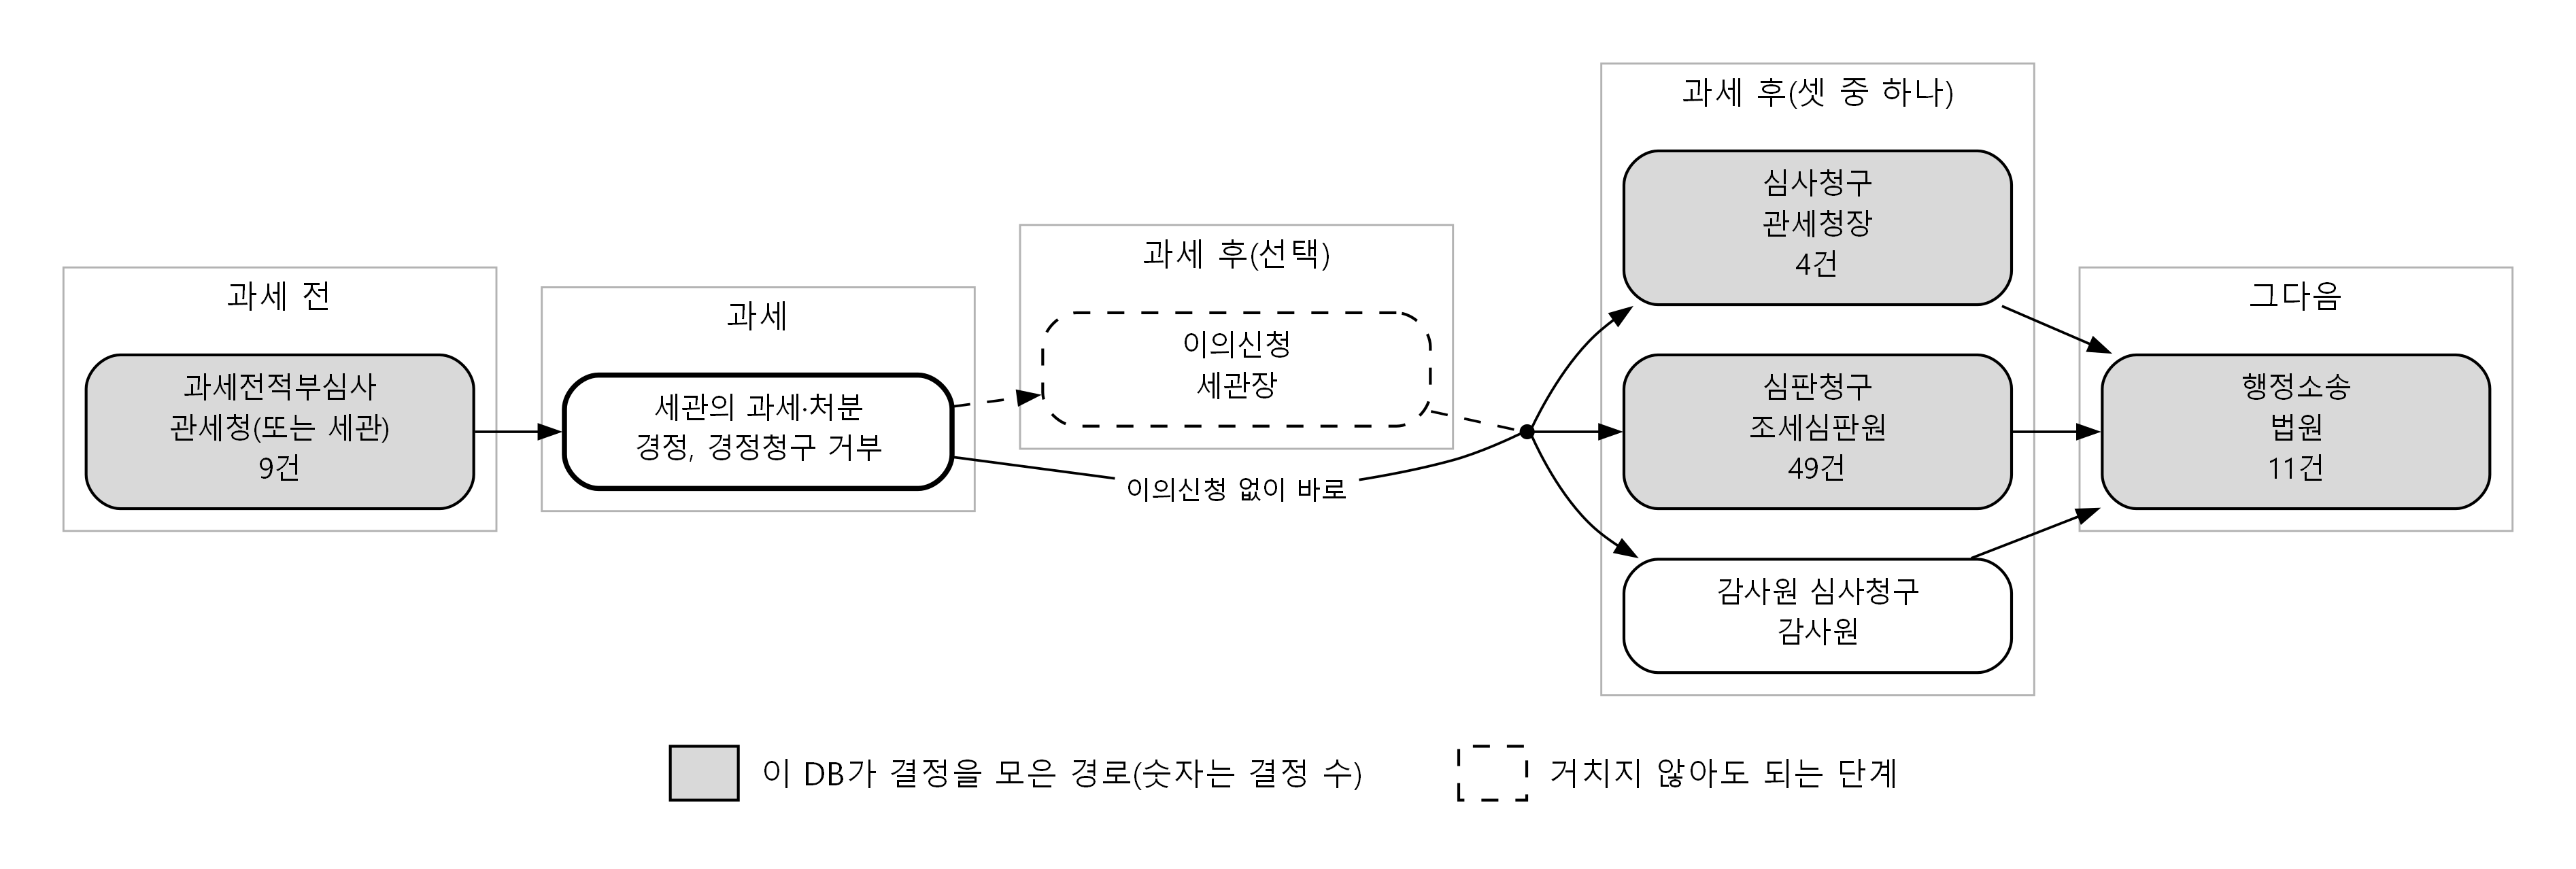

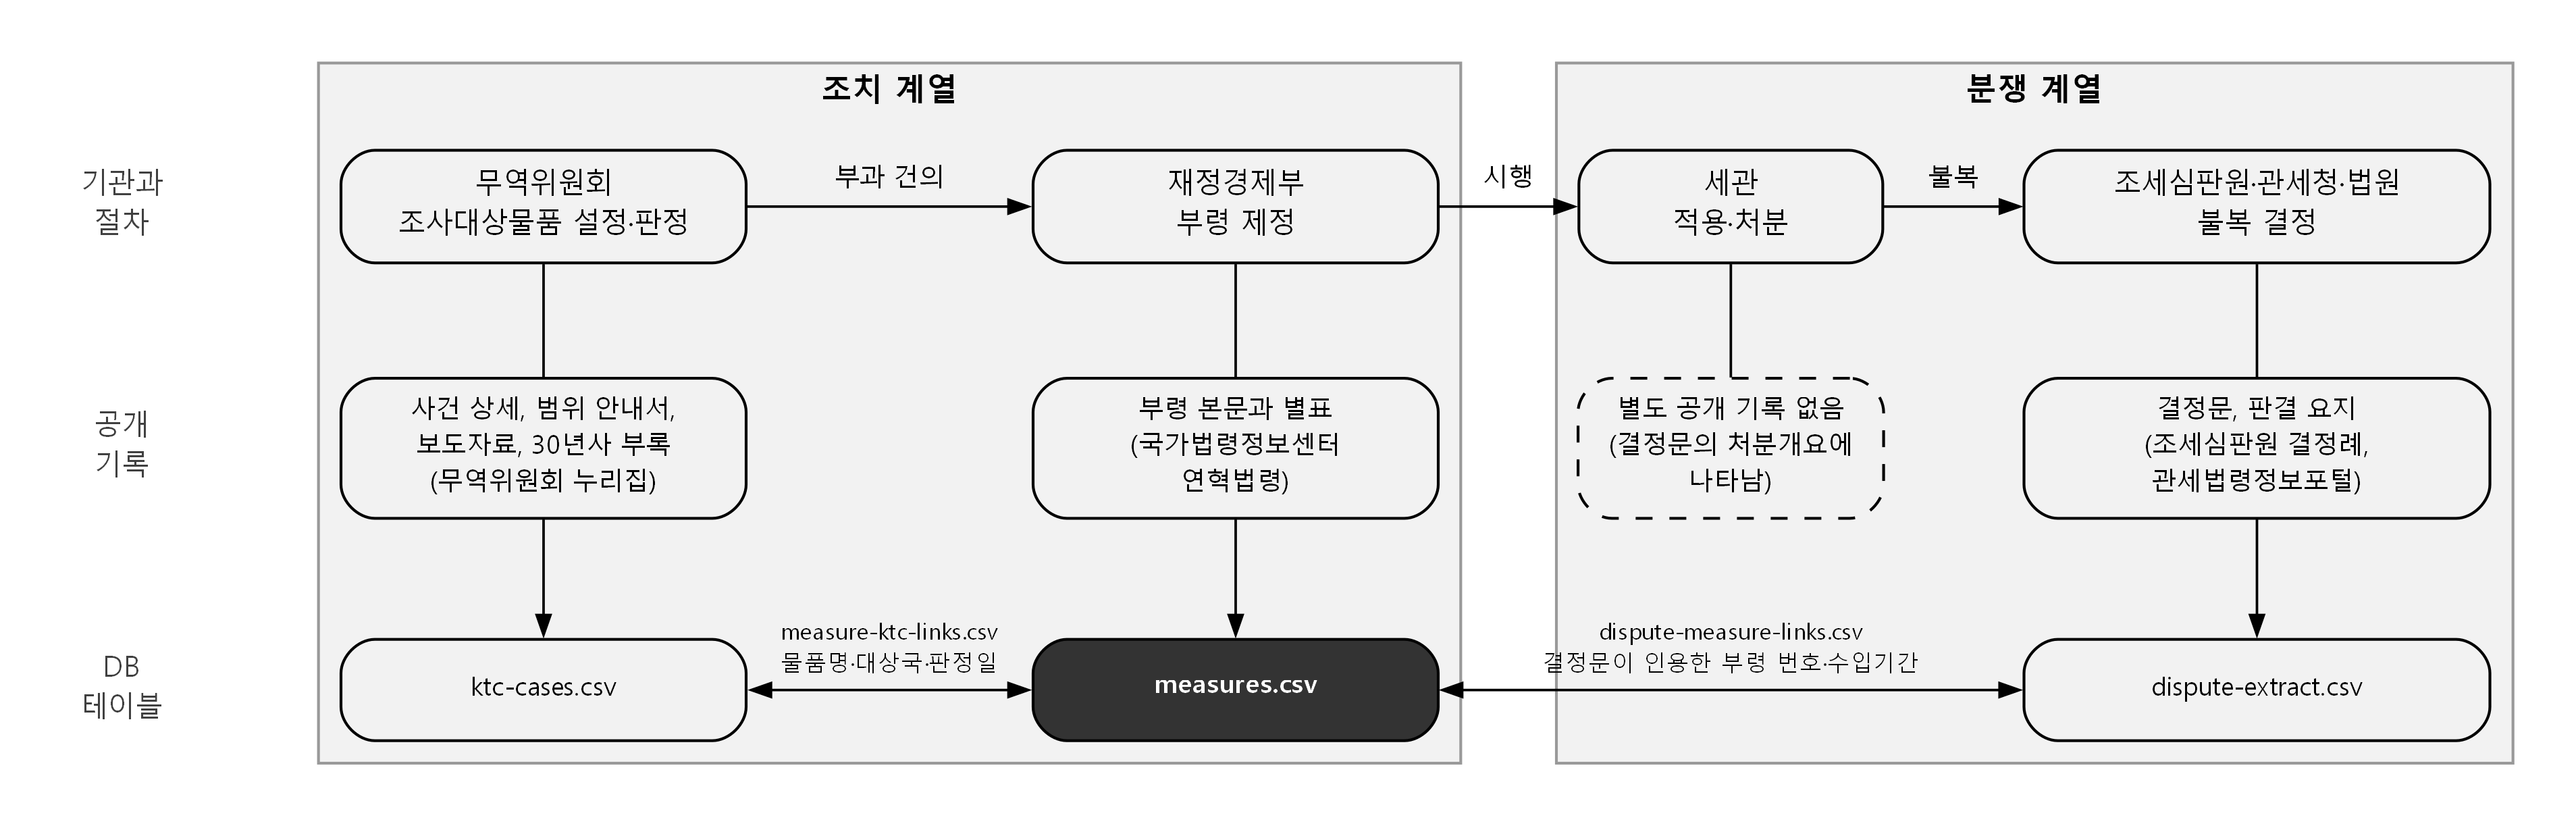

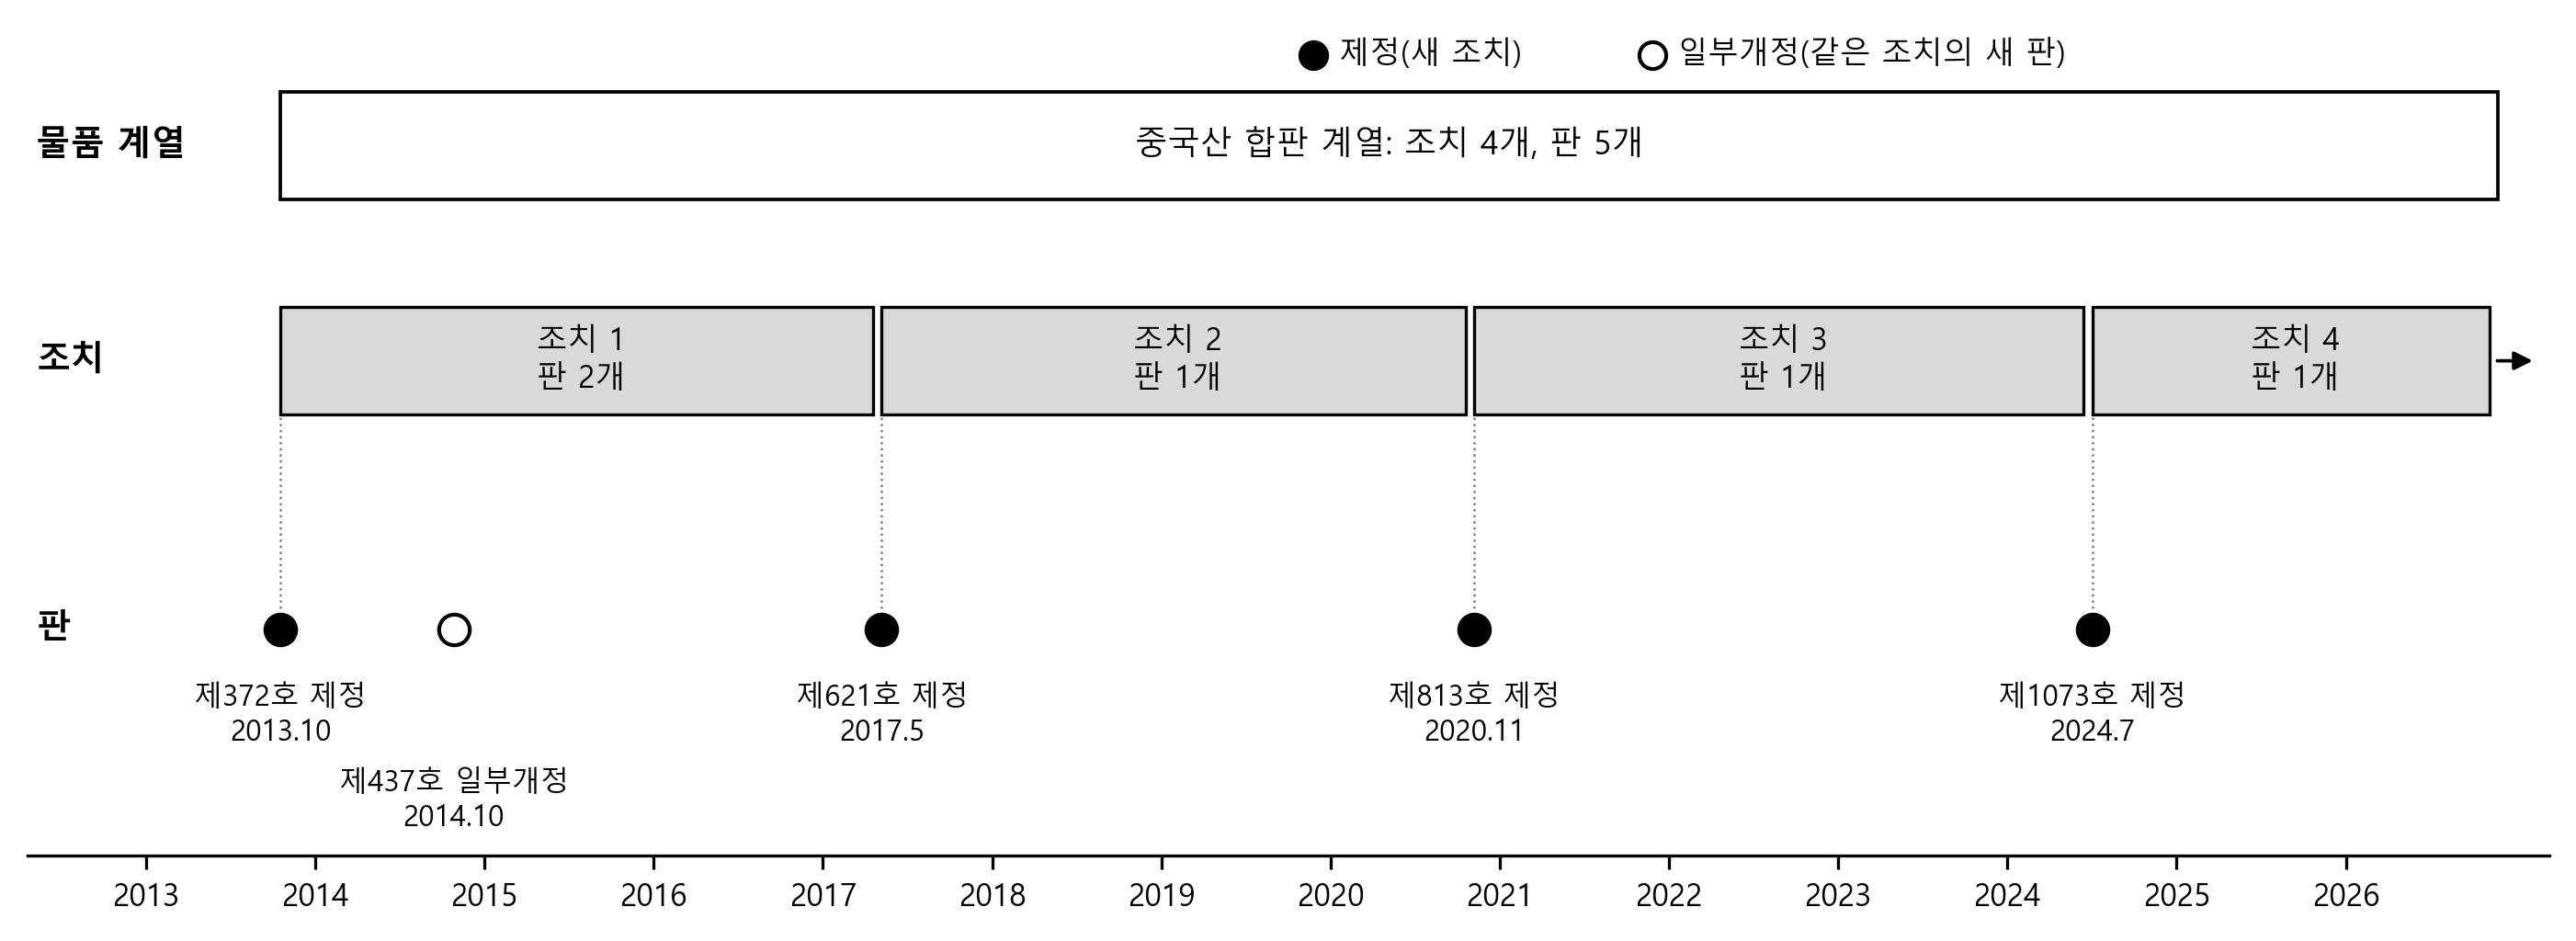

In [15]:
from IPython.display import Image, display
fig1_appeal_routes()
fig2_linkage_structure()
fig3_units_plywood()
for name in ("fig1_appeal_routes", "fig2_linkage_structure", "fig3_units_plywood"):
    display(Image(filename=str(IMG / f"{name}.png"), width=900))

## §11. 검증

본문이 인용한 수치를 계산 값과 대조한다. 하나라도 어긋나면 AssertionError로 멈춘다.

In [16]:
def chk(key, want):
    got = OUT[key]
    ok = got == want
    print(("OK  " if ok else "FAIL") + f" {key}: 계산 {got} / 본문 {want}")
    assert ok, f"{key}: 계산 {got} != 본문 {want}"

# 요약, V.1 표 9
chk("조치", 145); chk("판", 174); chk("조치_계열", 92); chk("별표", 191)
chk("결정", 73); chk("결정_연관", {"쟁점": 57, "언급": 9, "무관": 7})
chk("결정_기관", {"조세심판원": 49, "법원": 11, "관세청 과세전적부심사": 9, "관세청 심사청구": 4})
chk("무역위_사건", 229); chk("조치_사건연결", 145); chk("분쟁_대상", 57); chk("분쟁_연결", 55)
chk("범위안내서_파일", 80); chk("범위안내서_사건", 60); chk("보도자료", 124); chk("30년사_행", 156)
# V.2, V.4, V.5
chk("조치_연대", {"1990년대": 23, "2000년대": 33, "2010년대": 47, "2020년대": 42})
chk("결정문_묶음", 66); chk("분쟁_연쇄", 43)
chk("회신", 81); chk("회신_범위", 42); chk("회신_범위_서로다른", 24)
chk("사건요약", 206)
chk("무역위_사건_종류", {"원심": 126, "종료재심사": 60, "재심(종류 미상)": 35, "중간재심사": 4,
                        "가격약속 검토": 2, "중간재심사(부과대상 제외)": 2})
# VI.1 표 11
chk("부과조건_요약", {"없음": 59, "복합": 44, "규격": 33, "가공상태": 5, "용도": 4})
chk("제외_요약", {"없음": 81, "복합": 34, "가공상태": 15, "규격": 9, "용도": 5, "제품지정": 1})
chk("제외_위치", {"없음": 81, "본문": 37, "별표": 23, "둘다": 4})
chk("용도조건", 29)
assert OUT["유형별_조치수"]["부과_규격"] == 74
chk("연대별_제외요건", {"1990년대": "7/23", "2000년대": "16/33", "2010년대": "20/47", "2020년대": "21/42"})
# VI.2 표 12
chk("범위분쟁_조치", 23); chk("범위분쟁_계열", 12); chk("계열_전체", 92)
chk("교차_용도_조치", {"N": "17/116", "Y": "6/29"}); chk("교차_용도_계열", {"N": "9/73", "Y": "3/20"})
chk("교차_제외유무_조치", {"N": "13/81", "Y": "10/64"})
chk("교차_제외요약_조치", {"가공상태": "2/15", "규격": "0/9", "복합": "8/34", "없음": "13/81", "용도": "0/5", "제품지정": "0/1"})
# VI.3 표 13, VI.4
chk("범위분쟁_결정", 26); chk("범위분쟁_결정문", 22); chk("범위분쟁_분쟁", 16)
chk("판단기준", {"분류": 20, "가공상태": 17, "규격": 12, "용도": 2, "제품지정": 1})
chk("범위분쟁_무역위언급", 16)
chk("시행후_결정_중앙값_년", 5.7); chk("시행후_결정_범위_년", (0.2, 11.4))
chk("본안_납세자승", {"가격약속·과세가격": "0/2", "공급자·세율": "2/12", "기타": "0/6", "불복 적격": "0/1", "조사범위": "5/26"})
chk("범위분쟁_기관별_승", {"관세청 심사청구": "0/2", "조세심판원": "3/16", "법원": "0/2", "관세청 과세전적부심사": "2/6"})
# VI.5 표 14
chk("범위회신_있는결정", 16); chk("복수기관_결정", 8); chk("상충회신_결정", 5); chk("상충회신_결정문", 4)
chk("기관별_채택", {"무역위원회": {"Y": 11, "불명": 9, "N": 2}, "기획재정부": {"Y": 3, "불명": 5, "N": 3},
                   "관세청": {"불명": 4, "N": 3}, "세관": {"Y": 2}})
# VI.7 표 15
chk("HSK_2012", (10, 0, 0)); chk("HSK_2017", (13, 2, 0)); chk("HSK_2022", (18, 4, 4))
# VI.8, II.1
assert OUT["신청인_상위"]["한국합판보드협회"] == 20
chk("가격약속_사건", 30); chk("범위변경재심", 2)
assert OUT["계열당_조치수_분포"][1] == 63 and OUT["계열당_조치수_분포"][5] == 4
top = OUT["범위분쟁_계열별_결정연결수"]
assert top["중국및인도산PET필름"] == 18 and top["중국산도자기질타일"] == 5 and top["중국산합판"] == 5
chk("원심개시_2018_2023_범위", (1, 5)); chk("원심개시_2024_2025", (8, 8))
# V.8
chk("data_폴더_MB", 2.7); assert OUT["최장_테이블"][1] == 229; chk("최근_결정일", "2026-08-19")
print("\n본문 수치 대조 통과")

OK   조치: 계산 145 / 본문 145
OK   판: 계산 174 / 본문 174
OK   조치_계열: 계산 92 / 본문 92
OK   별표: 계산 191 / 본문 191
OK   결정: 계산 73 / 본문 73
OK   결정_연관: 계산 {'쟁점': 57, '언급': 9, '무관': 7} / 본문 {'쟁점': 57, '언급': 9, '무관': 7}
OK   결정_기관: 계산 {'조세심판원': 49, '법원': 11, '관세청 과세전적부심사': 9, '관세청 심사청구': 4} / 본문 {'조세심판원': 49, '법원': 11, '관세청 과세전적부심사': 9, '관세청 심사청구': 4}
OK   무역위_사건: 계산 229 / 본문 229
OK   조치_사건연결: 계산 145 / 본문 145
OK   분쟁_대상: 계산 57 / 본문 57
OK   분쟁_연결: 계산 55 / 본문 55
OK   범위안내서_파일: 계산 80 / 본문 80
OK   범위안내서_사건: 계산 60 / 본문 60
OK   보도자료: 계산 124 / 본문 124
OK   30년사_행: 계산 156 / 본문 156
OK   조치_연대: 계산 {'1990년대': 23, '2000년대': 33, '2010년대': 47, '2020년대': 42} / 본문 {'1990년대': 23, '2000년대': 33, '2010년대': 47, '2020년대': 42}
OK   결정문_묶음: 계산 66 / 본문 66
OK   분쟁_연쇄: 계산 43 / 본문 43
OK   회신: 계산 81 / 본문 81
OK   회신_범위: 계산 42 / 본문 42
OK   회신_범위_서로다른: 계산 24 / 본문 24
OK   사건요약: 계산 206 / 본문 206
OK   무역위_사건_종류: 계산 {'원심': 126, '종료재심사': 60, '재심(종류 미상)': 35, '중간재심사': 4, '가격약속 검토': 2, '중간재심사(부과대상 제외)': 2} / 본문 {'원심': 126, '종료재심사': 60, '재심(종류 미